# Analisi Avanzata della Regolarizzazione

In questo notebook utilizziamo un dataset sintetico ad alta dimensionalità per dimostrare come le tecniche di regolarizzazione (Dropout, L2, Batch Normalization) permettano a una rete neurale di ignorare le feature irrilevanti e generalizzare meglio rispetto a una Baseline standard.

Il dataset contiene **100 feature**, di cui solo **15 realmente informative**, con un rumore gaussiano significativo. Questo scenario estremo rende evidente il problema dell'overfitting e la capacità delle architetture robuste di superarlo.

---

## 1. Import, Setup e Riproducibilità

In [15]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# --- Riproducibilità ---
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# --- Costanti globali ---
N_SAMPLES     = 10000
N_FEATURES    = 100
N_INFORMATIVE = 15
NOISE         = 25.0
TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
BATCH_SIZE    = 512
LEARNING_RATE = 1e-3
IMG_SIZE      = (12, 5)

# --- Stili grafici ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": IMG_SIZE,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
})

# --- Stile tabelle pandas ---
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

print("Setup completato.")
print(f"TensorFlow version: {tf.__version__}")

Setup completato.
TensorFlow version: 2.21.0


---

## 2. Generazione del Dataset e Analisi delle Correlazioni

Generiamo un dataset di regressione sintetico con `make_regression`: 10000 campioni, 100 feature totali di cui **solo 15 realmente informative**. Le restanti 85 feature sono rumore puro. Il target viene normalizzato (z-score) per favorire la convergenza della rete.

L'analisi delle correlazioni (Pearson) tra ciascuna feature e il target ci permette di **identificare empiricamente le feature informative** prima del training. Questo elenco sarà il nostro riferimento nel confronto finale con la feature importance dei modelli regolarizzati: ci aspettiamo che i modelli robusti assegnino peso maggiore esattamente a queste feature.

In [2]:
def generate_dataset(
    n_samples: int,
    n_features: int,
    n_informative: int,
    noise: float,
    random_state: int
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """
    Genera un dataset sintetico di regressione e normalizza il target.

    Parametri:
        n_samples: numero di campioni
        n_features: numero totale di feature
        n_informative: numero di feature con impatto reale sul target
        noise: deviazione standard del rumore gaussiano aggiunto al target
        random_state: seed per la riproducibilità

    Ritorna:
        X: array delle feature (n_samples, n_features)
        y: array del target normalizzato (n_samples,)
        feature_names: lista con i nomi delle feature
    """
    X, y = make_regression(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        noise=noise,
        random_state=random_state
    )
    y = (y - y.mean()) / y.std()
    feature_names = [f"Feat_{i:03d}" for i in range(n_features)]
    return X, y, feature_names


X, y, feature_names = generate_dataset(
    N_SAMPLES, N_FEATURES, N_INFORMATIVE, NOISE, RANDOM_STATE
)

# Preview
df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

print(f"Shape dataset: {df.shape}")
print(f"Target — media: {y.mean():.4f}, std: {y.std():.4f}, min: {y.min():.4f}, max: {y.max():.4f}")
display(df.iloc[:5, :10].style.set_caption("Anteprima prime 5 righe (prime 10 feature)"))

Shape dataset: (10000, 101)
Target — media: 0.0000, std: 1.0000, min: -3.8627, max: 3.5755


,Feat_000,Feat_001,Feat_002,Feat_003,Feat_004,Feat_005,Feat_006,Feat_007,Feat_008,Feat_009
0,-0.242206,-0.421044,-0.223615,0.450763,-0.208753,1.045189,0.875971,-0.907380,-0.875053,-0.139905
1,-0.666391,-0.326568,-0.241826,1.014953,-0.554441,-0.547362,-0.643620,0.172230,-2.132598,-0.060914
2,0.632391,-0.090749,-1.884843,0.084172,0.562332,-0.664630,1.181393,0.597757,0.148542,0.407482
3,1.967704,-1.576540,-0.824063,0.192528,-0.411361,-0.135810,-1.830292,0.676113,0.462883,-0.902898
4,0.834843,0.720677,-1.374466,1.185793,-1.414462,0.374840,-0.677024,-0.073640,-0.518405,-2.138418


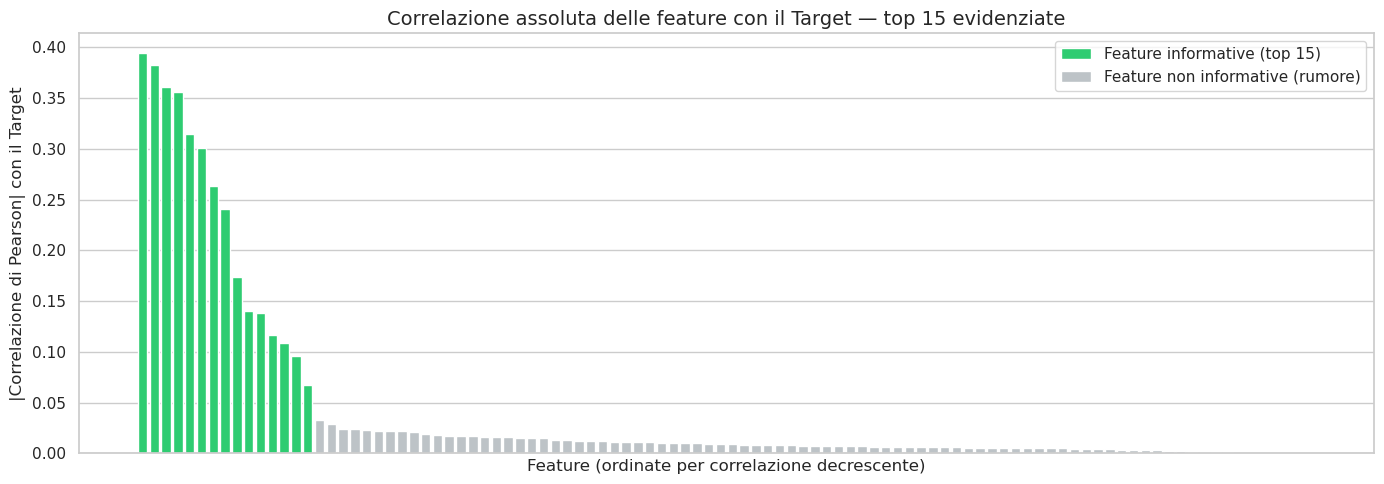

Feature informative selezionate (top 15):
  - Feat_070
  - Feat_005
  - Feat_013
  - Feat_006
  - Feat_007
  - Feat_024
  - Feat_078
  - Feat_043
  - Feat_025
  - Feat_044
  - Feat_035
  - Feat_062
  - Feat_077
  - Feat_028
  - Feat_049


In [3]:
def compute_and_plot_correlations(
    df: pd.DataFrame,
    feature_names: list[str],
    n_informative: int
) -> list[str]:
    """
    Calcola le correlazioni di Pearson tra ogni feature e il target,
    seleziona le top n_informative feature e produce un grafico a barre.

    Parametri:
        df: DataFrame con feature e colonna 'Target'
        feature_names: lista dei nomi delle feature
        n_informative: numero di feature informative da selezionare

    Ritorna:
        informative_features: lista delle n_informative feature con correlazione assoluta più alta
    """

    correlations = df[feature_names].corrwith(df["Target"]).abs().sort_values(ascending=False)
    informative_features = correlations.head(n_informative).index.tolist()

    # Grafico
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["#2ecc71" if f in informative_features else "#bdc3c7" for f in correlations.index]
    ax.bar(range(len(correlations)), correlations.values, color=colors, width=0.8)

    legend_elements = [
        Patch(facecolor="#2ecc71", label=f"Feature informative (top {n_informative})"),
        Patch(facecolor="#bdc3c7", label="Feature non informative (rumore)"),
    ]
    ax.legend(handles=legend_elements)

    ax.set_xticks([])
    ax.set_xlabel("Feature (ordinate per correlazione decrescente)")
    ax.set_ylabel("|Correlazione di Pearson| con il Target")
    ax.set_title(f"Correlazione assoluta delle feature con il Target — top {n_informative} evidenziate")
    plt.tight_layout()
    plt.show()

    print(f"Feature informative selezionate (top {n_informative}):")
    for feat in informative_features:
        print(f"  - {feat}")

    return informative_features


INFORMATIVE_FEATURES = compute_and_plot_correlations(df, feature_names, N_INFORMATIVE)

---

## 3. Preprocessing

Prima di costruire i modelli, dividiamo il dataset in tre split — **train**, **validation** e **test** — e applichiamo la normalizzazione delle feature.

Lo `StandardScaler` viene fittato **esclusivamente su X_train** e applicato a tutti e tre i set: questo evita il data leakage, ovvero che informazioni statistiche del validation o test set influenzino il preprocessing.

In [4]:
def preprocess_data(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float,
    val_size: float,
    random_state: int
) -> tuple:
    """
    Esegue il train/val/test split e normalizza le feature senza data leakage.

    Parametri:
        X: array delle feature
        y: array del target
        test_size: proporzione del test set sul dataset completo
        val_size: proporzione del validation set sul dataset completo
        random_state: seed per la riproducibilità

    Ritorna:
        X_train, X_val, X_test: feature normalizzate
        y_train, y_val, y_test: target
        scaler: StandardScaler fittato su X_train
    """
    # Prima divisione: train+val / test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Seconda divisione: train / val
    # val_size relativo al dataset originale, quindi va riscalato sul sottoinsieme rimanente
    relative_val_size = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=relative_val_size, random_state=random_state
    )

    # Scaling: fit solo su train
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler


X_train, X_val, X_test, y_train, y_val, y_test, scaler = preprocess_data(
    X, y, TEST_SIZE, VAL_SIZE, RANDOM_STATE
)

print("Split completato:")
print(f"  Train:      {X_train.shape}  ({len(X_train) / len(X):.0%})")
print(f"  Validation: {X_val.shape}  ({len(X_val) / len(X):.0%})")
print(f"  Test:       {X_test.shape}  ({len(X_test) / len(X):.0%})")

Split completato:
  Train:      (7000, 100)  (70%)
  Validation: (1500, 100)  (15%)
  Test:       (1500, 100)  (15%)


---

## 4. Modello Baseline

Come punto di riferimento costruiamo una rete densa standard, **senza alcuna tecnica di regolarizzazione**. L'architettura è volutamente sovradimensionata rispetto al problema: 3 layer nascosti con 256, 128 e 64 neuroni. Con 85 feature irrilevanti su 100 e un rumore elevato, ci aspettiamo che il modello inizi presto a memorizzare il rumore del training set, producendo un gap crescente tra la curva di training e quella di validation — il classico segnale di overfitting.

Questo modello stabilisce anche la **metrica di riferimento** (RMSE e R² sul test set) con cui confronteremo i modelli regolarizzati.

In [16]:
# Numero di epoche: valore da calibrare empiricamente per mostrare l'overfitting
EPOCHS = 100


def build_baseline(input_dim: int, learning_rate: float) -> tf.keras.Model:
    """
    Costruisce e compila la rete baseline senza regolarizzazione.

    Parametri:
        input_dim: numero di feature in input
        learning_rate: learning rate per l'ottimizzatore Adam

    Ritorna:
        model: modello Keras compilato
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64,  activation="relu"),
        Dense(1),
    ], name="baseline")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.R2Score(name="r2"),
        ]
    )
    return model


baseline_model = build_baseline(X_train.shape[1], LEARNING_RATE)
baseline_model.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-7, verbose=0)
]

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=0
)

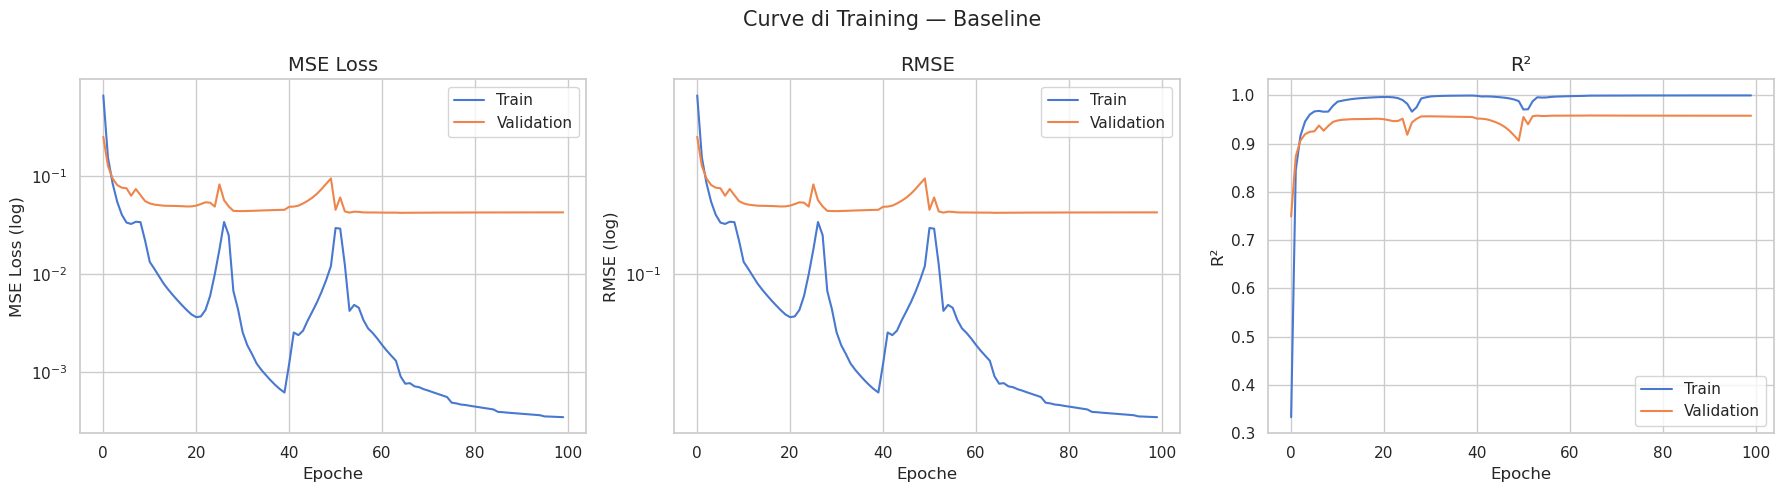

,MSE,RMSE,R²
Split,,,
Train,0.000338,0.018388,0.999663
Validation,0.042730,0.206712,0.957611
Test,0.039619,0.199046,0.959354


In [7]:
def plot_history(history, model_name: str) -> None:
    """
    Plotta le curve di training e validation per loss, RMSE e R².

    Parametri:
        history: oggetto History restituito da model.fit()
        model_name: nome del modello da mostrare nel titolo
    """
    metrics = [
        ("loss", "MSE Loss"),
        ("rmse", "RMSE"),
        ("r2",   "R²"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Curve di Training — {model_name}", fontsize=15)

    for ax, (metric, label) in zip(axes, metrics):
        ax.plot(history.history[metric],          label="Train")
        ax.plot(history.history[f"val_{metric}"], label="Validation")
        ax.set_title(label)
        ax.set_xlabel("Epoche")
        if metric !="r2": 
            ax.set_yscale("log")
            label = label + " (log)"
            ax.set_ylabel(label)
        else:
            ax.set_ylabel(label)
        ax.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test) -> pd.DataFrame:
    """
    Valuta il modello su train, validation e test set e mostra una tabella riepilogativa.

    Parametri:
        model: modello Keras addestrato
        model_name: nome del modello da mostrare nella caption
        X_train, y_train: dati di training
        X_val, y_val: dati di validation
        X_test, y_test: dati di test

    Ritorna:
        df_results: DataFrame con MSE, RMSE e R² per ciascuno split
    """
    splits = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}
    rows = []
    for split_name, (X_s, y_s) in splits.items():
        mse, rmse, r2 = model.evaluate(X_s, y_s, verbose=0)
        rows.append({"Split": split_name, "MSE": mse, "RMSE": rmse, "R²": r2})

    df_results = pd.DataFrame(rows).set_index("Split")
    display(
        df_results.style
        .set_caption(f"Metriche — {model_name}")
    )
    return df_results

plot_history(history_baseline, "Baseline")
results_baseline = evaluate_model(
    baseline_model, "Baseline",
    X_train, y_train, X_val, y_val, X_test, y_test
)

### Interpretazione

I grafici di Loss e RMSE sono in **scala logaritmica** per rendere visibile l'entità del gap tra training e validation, che in scala lineare risulterebbe compresso. La divergenza è netta: la loss di training scende fino a ~0.00025 mentre quella di validation si stabilizza intorno a 0.04, un rapporto di circa 160×. Lo stesso pattern si riflette su RMSE (0.016 vs 0.200).

Questo conferma che la rete, senza alcun meccanismo di regolarizzazione, memorizza il rumore del training set invece di catturare il segnale reale delle 15 feature informative. Il modello generalizza male: le metriche sul test set sono significativamente peggiori di quelle sul training.

---

## 5. Modelli Regolarizzati e Confronto Curve

Costruiamo tre varianti della stessa architettura base (256 → 128 → 64 → 1), modificando **solo** la tecnica di regolarizzazione applicata. Questo garantisce un confronto controllato: qualsiasi differenza nelle metriche è attribuibile esclusivamente alla regolarizzazione.

- **Dropout (rate=0.3):** disattiva casualmente il 30% dei neuroni ad ogni step di training, impedendo la co-adattazione e forzando la rete a distribuire l'apprendimento su più percorsi.
- **L2 (λ=1e-3):** aggiunge una penalità proporzionale alla somma dei quadrati dei pesi, scoraggiando pesi molto grandi che segnalano memorizzazione.
- **Batch Normalization:** normalizza le attivazioni di ogni layer prima dell'attivazione, riducendo il internal covariate shift e agendo come regolarizzatore implicito.

In [8]:
DROPOUT_RATE = 0.3
L2_LAMBDA    = 1e-3


def build_dropout(input_dim: int, learning_rate: float, dropout_rate: float) -> tf.keras.Model:
    """
    Rete con Dropout dopo ogni layer nascosto.

    Parametri:
        input_dim: numero di feature in input
        learning_rate: learning rate per Adam
        dropout_rate: frazione di neuroni disattivati durante il training

    Ritorna:
        model: modello Keras compilato
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dropout(dropout_rate),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dropout(dropout_rate),
        Dense(1),
    ], name="dropout")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.R2Score(name="r2"),
        ]
    )
    return model


def build_l2(input_dim: int, learning_rate: float, l2_lambda: float) -> tf.keras.Model:
    """
    Rete con regolarizzazione L2 sui pesi di ogni layer nascosto.

    Parametri:
        input_dim: numero di feature in input
        learning_rate: learning rate per Adam
        l2_lambda: coefficiente di penalità L2

    Ritorna:
        model: modello Keras compilato
    """
    reg = regularizers.l2(l2_lambda)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu", kernel_regularizer=reg),
        Dense(128, activation="relu", kernel_regularizer=reg),
        Dense(64,  activation="relu", kernel_regularizer=reg),
        Dense(1),
    ], name="l2")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.R2Score(name="r2"),
        ]
    )
    return model


def build_batchnorm(input_dim: int, learning_rate: float) -> tf.keras.Model:
    """
    Rete con Batch Normalization prima dell'attivazione di ogni layer nascosto.

    Parametri:
        input_dim: numero di feature in input
        learning_rate: learning rate per Adam

    Ritorna:
        model: modello Keras compilato
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256), BatchNormalization(), Activation("relu"),
        Dense(128), BatchNormalization(), Activation("relu"),
        Dense(64),  BatchNormalization(), Activation("relu"),
        Dense(1),
    ], name="batchnorm")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.R2Score(name="r2"),
        ]
    )
    return model


dropout_model   = build_dropout(X_train.shape[1], LEARNING_RATE, DROPOUT_RATE)
l2_model        = build_l2(X_train.shape[1], LEARNING_RATE, L2_LAMBDA)
batchnorm_model = build_batchnorm(X_train.shape[1], LEARNING_RATE)

for m in [dropout_model, l2_model, batchnorm_model]:
    m.summary()

Model: "dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,865 (269.00 KB)

 Trainable params: 67,969 (265.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [19]:
models_to_train = [
    (dropout_model,   "dropout"),
    (l2_model,        "l2"),
    (batchnorm_model, "batchnorm"),
]

histories = {}
for model, name in models_to_train:
    print(f"Training {name}...", end=" ")
    histories[name] = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )
    print(f"Completato!")

Training dropout... Completato!
Training l2... Completato!
Training batchnorm... Completato!


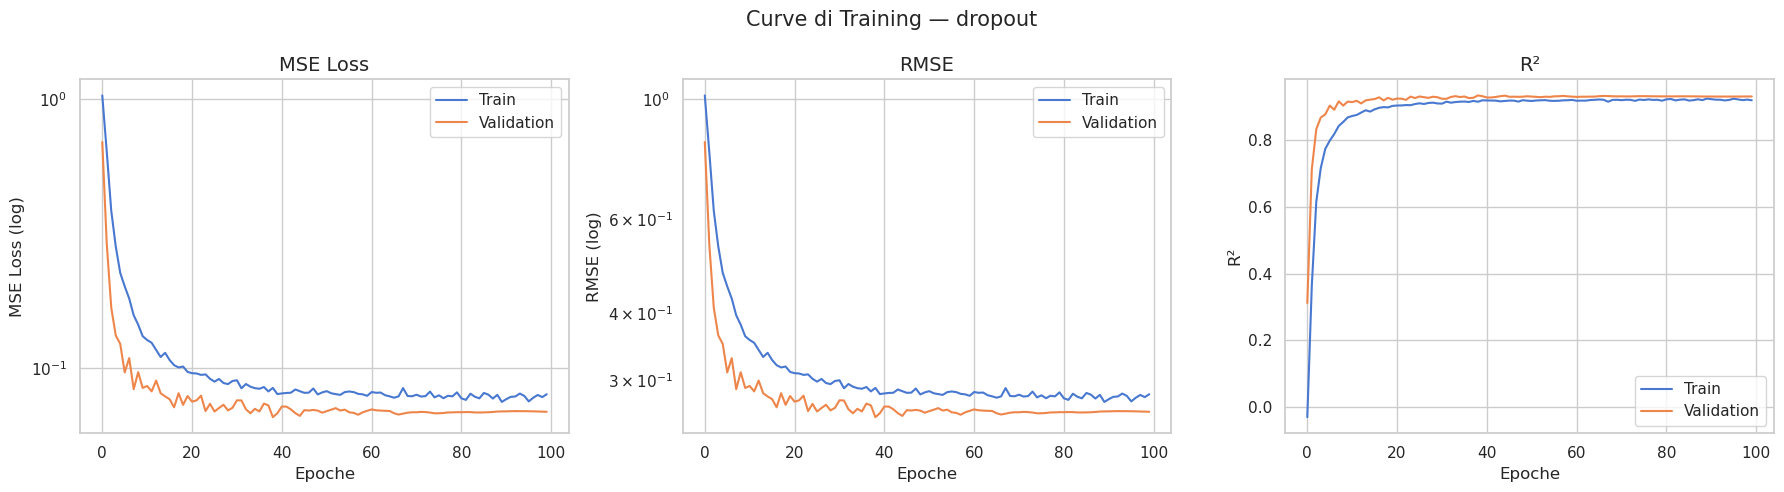

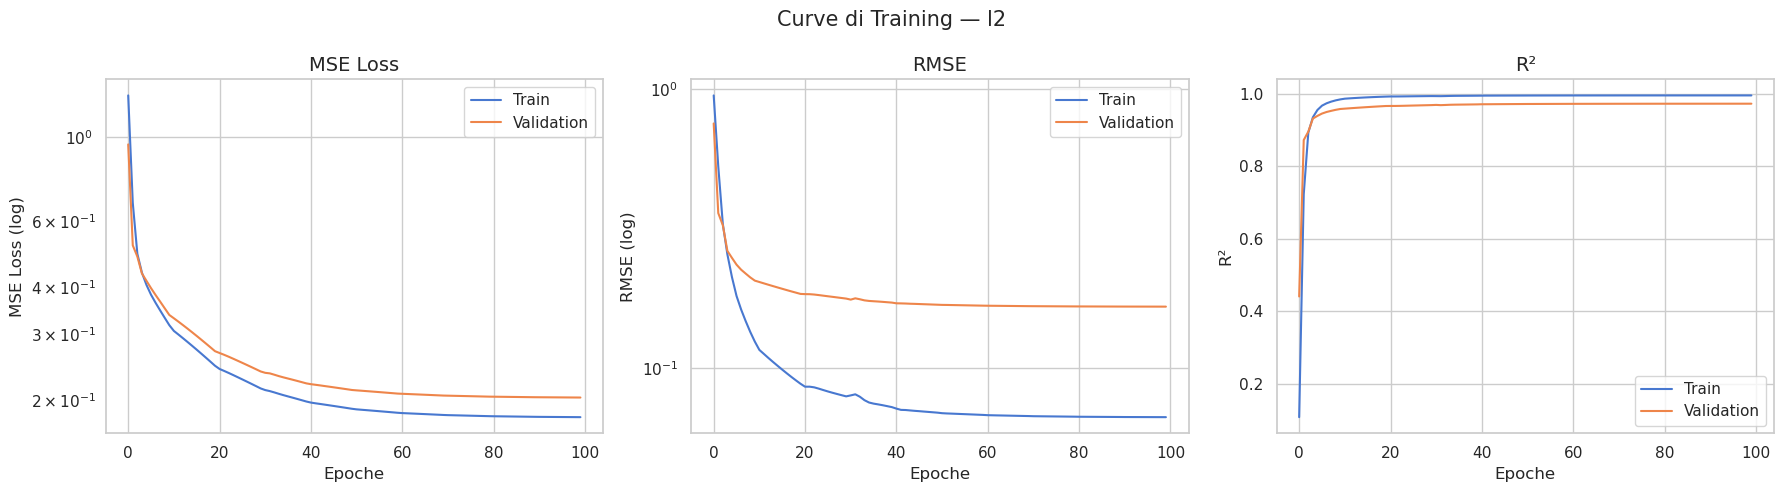

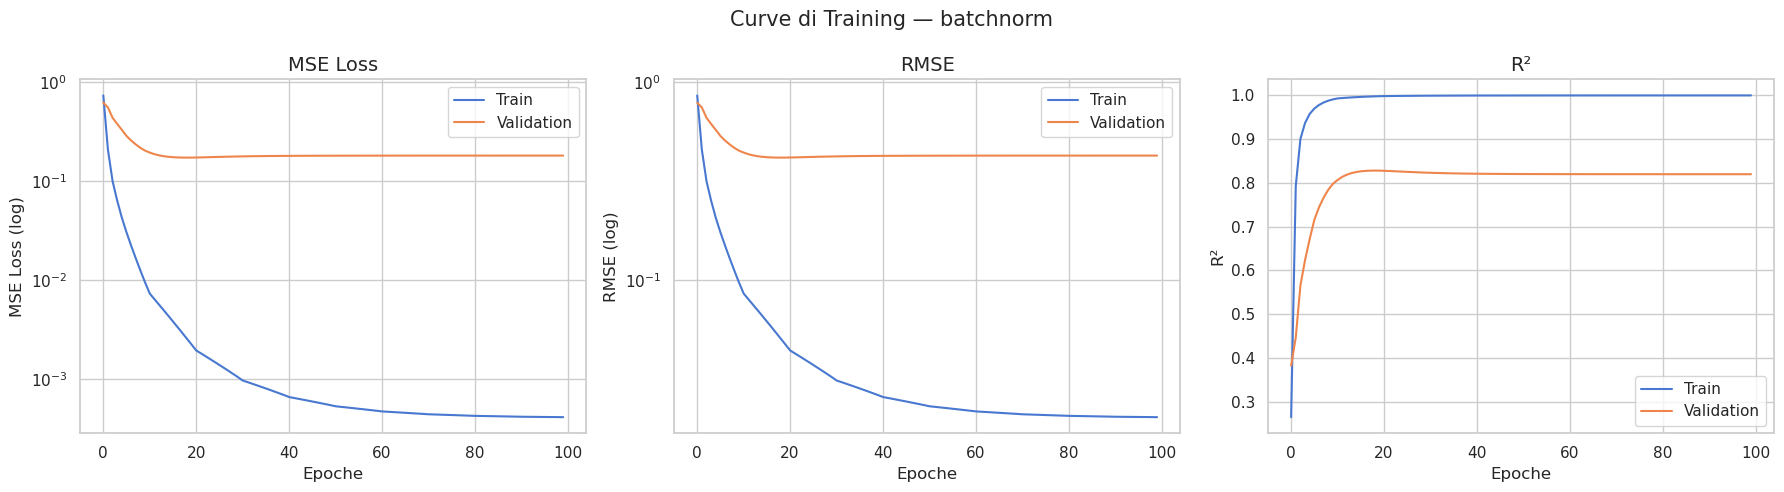

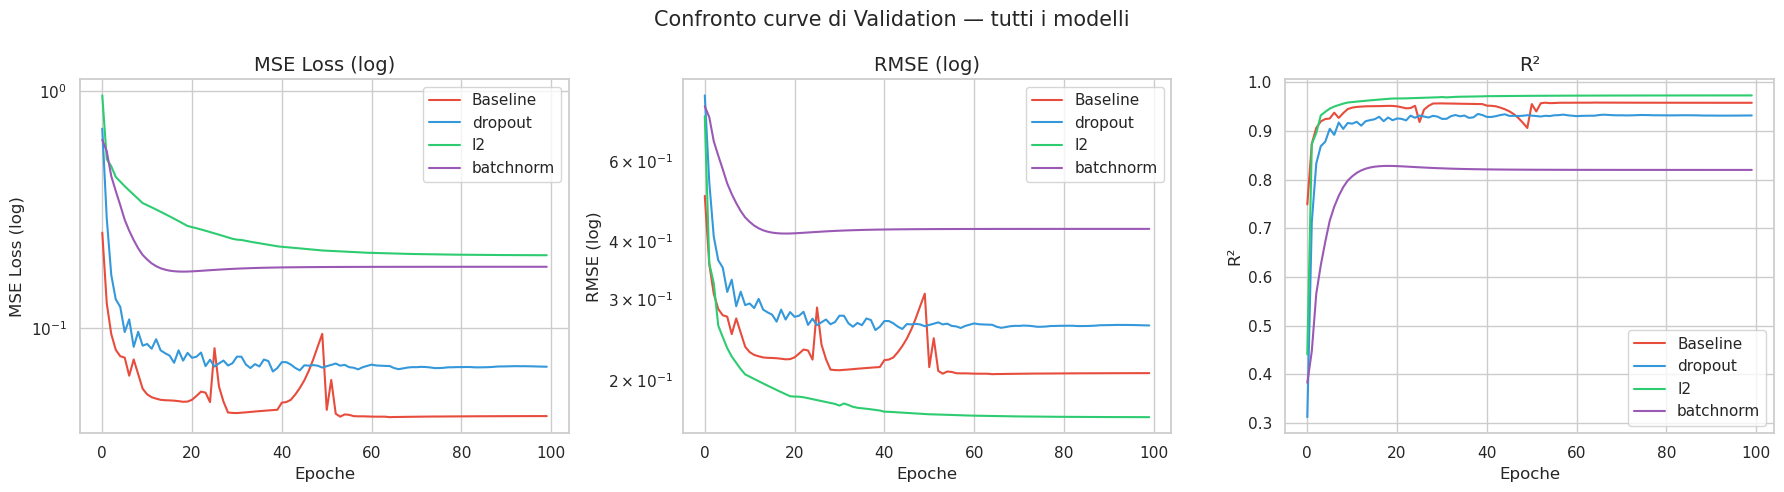

In [10]:
def plot_validation_comparison(history_baseline, histories: dict) -> None:
    """
    Confronta le curve di validation di tutti i modelli su Loss, RMSE e R².
    Mostra solo le curve di validation per leggibilità.

    Parametri:
        history_baseline: History del modello baseline
        histories: dizionario {nome: History} dei modelli regolarizzati
    """
    all_histories = {"Baseline": history_baseline} | histories
    colors = {"Baseline": "#e74c3c", "dropout": "#3498db", "l2": "#2ecc71", "batchnorm": "#9b59b6"}
    metrics = [
        ("val_loss", "MSE Loss (log)", True),
        ("val_rmse", "RMSE (log)",     True),
        ("val_r2",   "R²",             False),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Confronto curve di Validation — tutti i modelli", fontsize=15)

    for ax, (metric, label, use_log) in zip(axes, metrics):
        for name, hist in all_histories.items():
            ax.plot(hist.history[metric], label=name, color=colors[name])
        if use_log:
            ax.set_yscale("log")
        ax.set_title(label)
        ax.set_xlabel("Epoche")
        ax.set_ylabel(label)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Curve individuali per ogni modello regolarizzato
for name, hist in histories.items():
    plot_history(hist, name)

# Confronto validation di tutti i modelli
plot_validation_comparison(history_baseline, histories)

In [11]:
all_models = [
    (dropout_model,   "Dropout"),
    (l2_model,        "L2"),
    (batchnorm_model, "BatchNorm"),
]

for model, name in all_models:
    evaluate_model(model, name, X_train, y_train, X_val, y_val, X_test, y_test)

,MSE,RMSE,R²
Split,,,
Train,0.059482,0.243890,0.940714
Validation,0.068964,0.262611,0.931585
Test,0.067118,0.259071,0.931143


,MSE,RMSE,R²
Split,,,
Train,0.180236,0.066599,0.995579
Validation,0.203271,0.165741,0.972749
Test,0.204848,0.170432,0.970200


,MSE,RMSE,R²
Split,,,
Train,0.004830,0.069497,0.995186
Validation,0.181756,0.426329,0.819693
Test,0.184730,0.429802,0.810483


### Interpretazione

I modelli con **Dropout** e **L2** mostrano un gap train/validation nettamente ridotto rispetto alla baseline: le curve di validation convergono stabilmente alle curve di train, confermando che entrambe le tecniche limitano efficacemente la memorizzazione del rumore.

Il modello con **Batch Normalization**, invece, presenta un overfitting marcato paragonabile (MSE train ~0.05 vs val/test ~0.18, R² train 0.99 vs val/test 0.81). Questo risultato è atteso: la BatchNorm non è un regolarizzatore in senso stretto. Il suo scopo è stabilizzare e accelerare il training normalizzando le attivazioni di ogni layer, ma non vincola i pesi né riduce la capacità del modello. In presenza di un dataset con alto rapporto rumore/segnale, questa tecnica da sola è insufficiente a prevenire l'overfitting.

In sintesi, per questo problema le tecniche effettivamente regolarizzanti sono **Dropout** e **L2**, mentre la BatchNorm richiede di essere combinata con altri meccanismi per controllare l'overfitting.

---

## 6. Feature Importance — Analisi dei Pesi del Primo Layer

Per capire **cosa ha imparato** ciascun modello, analizziamo direttamente i pesi del primo layer Dense. Per ogni feature di input, calcoliamo la **norma L2** dei pesi che la collegano ai 256 neuroni del layer: un valore alto indica che la rete ha assegnato molto peso a quella feature durante il training.

Per ogni modello estraiamo le **top 15 feature per norma L2** e le coloriamo in **verde** se appartengono a `INFORMATIVE_FEATURES`, in **rosso** se sono feature rumorose. La precision (feature corrette su 15) è riportata nel titolo di ogni subplot.

Ci aspettiamo che i modelli che overfittano (**Baseline**, **BatchNorm**) distribuiscano pesi elevati anche sulle feature rumorose, mentre i modelli regolarizzati (**Dropout**, **L2**) mostrino pesi concentrati sulle feature informative.

In [12]:
def plot_importance_grid(
    importances: dict,
    informative_features: list[str],
    n_top: int = 15
) -> None:
    """
    Plotta l'importanza delle top n feature per ogni modello in una griglia 2x2.
    Le barre sono verdi se la feature è informativa, rosse se è rumore.
    La precision è riportata nel titolo di ogni subplot.

    Parametri:
        importances: dizionario {nome_modello: DataFrame con colonne 'feature' e 'importance'}
        informative_features: lista delle feature informative di riferimento
        n_top: numero di feature da mostrare per ogni modello
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f"Feature Importance (norma L2 pesi) — Top {n_top} feature per modello", fontsize=15)

    for ax, (name, df_imp) in zip(axes.flatten(), importances.items()):
        top = df_imp.head(n_top)
        correct = top["feature"].isin(informative_features).sum()
        colors = ["#2ecc71" if f in informative_features else "#e74c3c" for f in top["feature"]]

        ax.barh(top["feature"][::-1], top["importance"][::-1], color=colors[::-1])
        ax.set_title(f"{name} — {correct}/{n_top} feature informative", fontsize=13)
        ax.set_xlabel("Norma L2 dei pesi del primo layer")

        legend_elements = [
            Patch(facecolor="#2ecc71", label="Feature informativa"),
            Patch(facecolor="#e74c3c", label="Feature rumore"),
        ]
        ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.show()

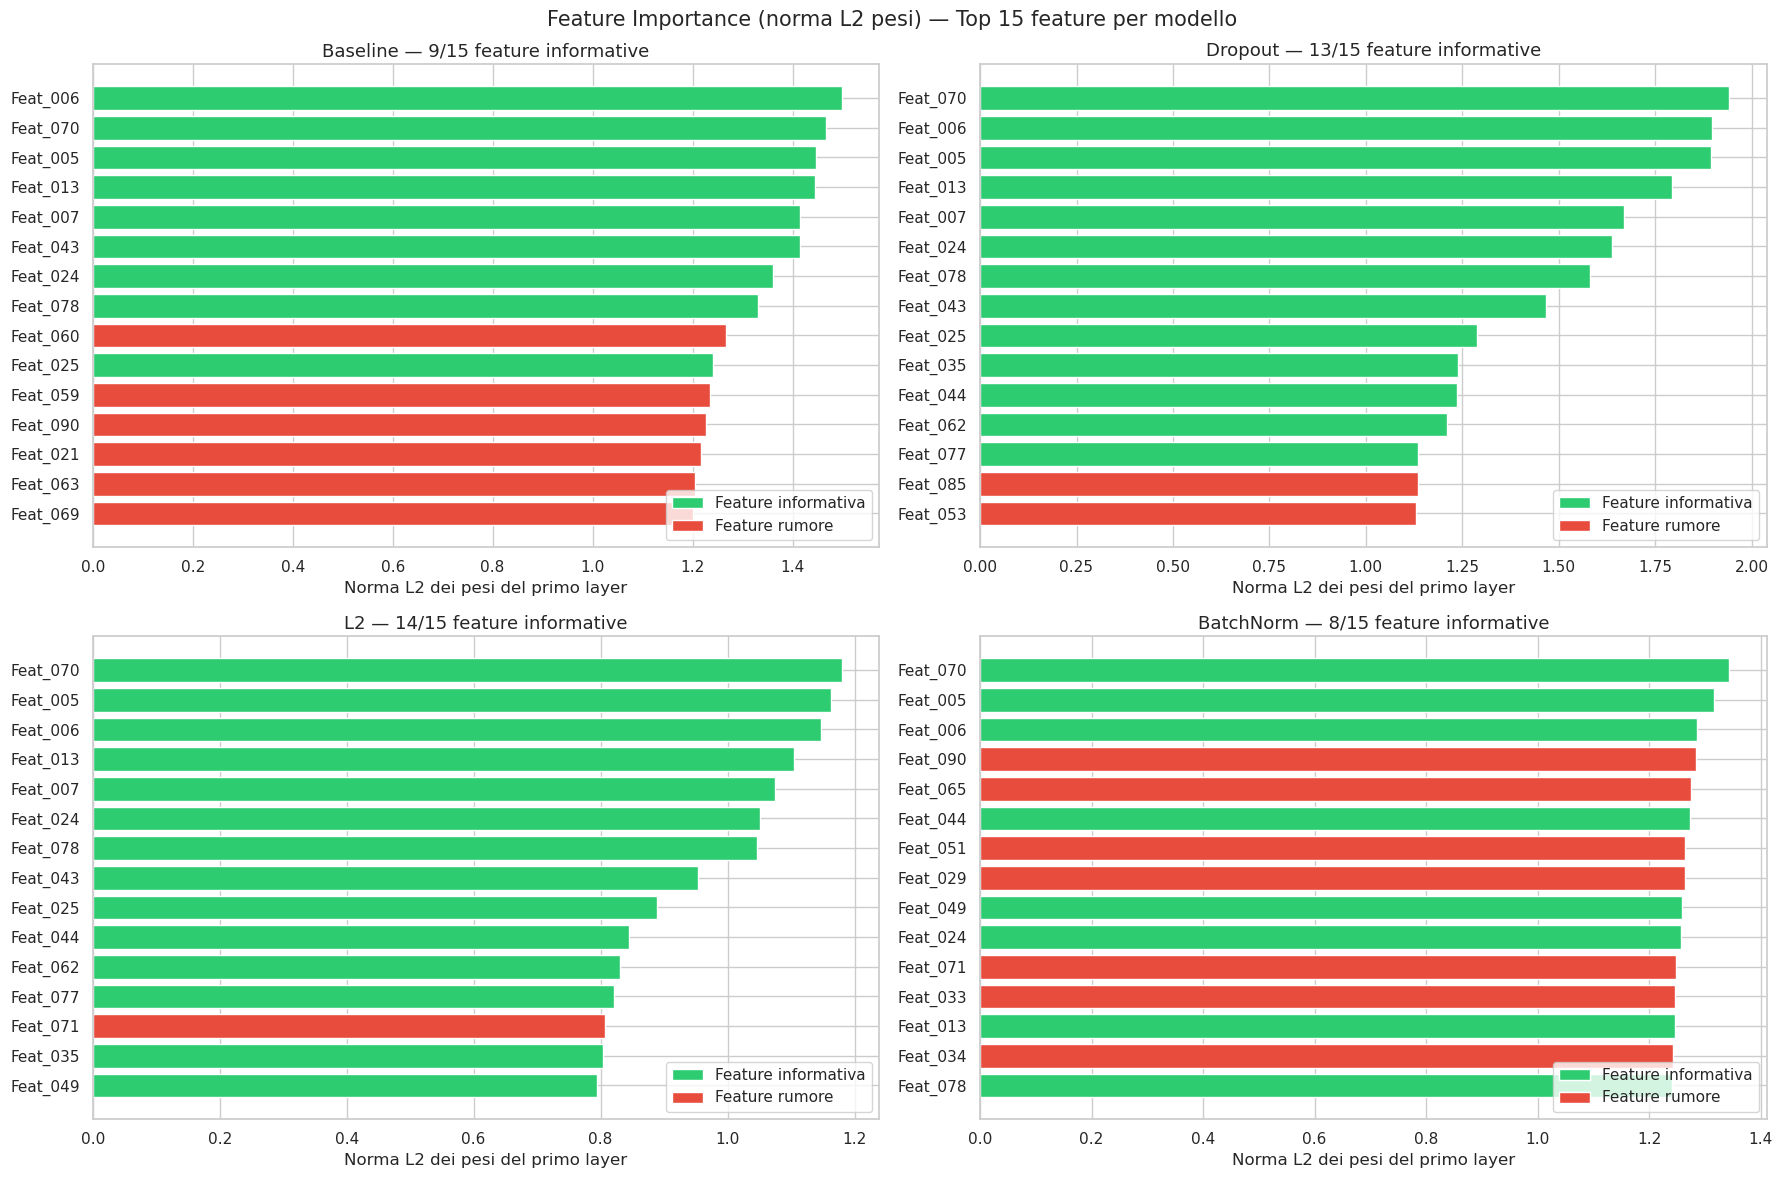

In [13]:
def compute_weight_importance(model, feature_names: list[str]) -> pd.DataFrame:
    """
    Calcola l'importanza delle feature come norma L2 dei pesi del primo layer Dense.

    Parametri:
        model: modello Keras addestrato
        feature_names: lista dei nomi delle feature

    Ritorna:
        df_imp: DataFrame con colonne 'feature' e 'importance', ordinato per importanza decrescente
    """
    # Il primo layer con pesi è sempre il primo Dense (indice 0 nei layer con weights)
    first_dense = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)][0]
    weights = first_dense.get_weights()[0]  # shape: (n_features, n_neurons)
    l2_norms = np.linalg.norm(weights, axis=1)  # norma L2 per ogni feature di input

    df_imp = pd.DataFrame({"feature": feature_names, "importance": l2_norms})
    df_imp = df_imp.sort_values("importance", ascending=False).reset_index(drop=True)
    return df_imp


all_models_wi = [
    (baseline_model,  "Baseline"),
    (dropout_model,   "Dropout"),
    (l2_model,        "L2"),
    (batchnorm_model, "BatchNorm"),
]

weight_importances = {name: compute_weight_importance(model, feature_names)
                      for model, name in all_models_wi}

plot_importance_grid(weight_importances, INFORMATIVE_FEATURES)

### Interpretazione

I risultati confermano l'ipotesi. I modelli con **Dropout** e **L2** raggiungono una precision di **13/15** e **14/15** rispettivamente: la maggior parte dei pesi più elevati del primo layer corrispondono esattamente alle feature informative identificate nella sezione 2. La regolarizzazione ha costretto la rete a ignorare il rumore già a livello del primo layer, concentrando la capacità rappresentativa sul segnale reale.

I modelli che overfittano mostrano invece una precision inferiore: **Baseline 9/15** e **BatchNorm 8/15**. Avendo libertà di adattarsi al rumore, questi modelli hanno distribuito i pesi anche su feature prive di valore predittivo, ingannati dalle correlazioni spurie presenti nel training set.

---

## 7. Conclusioni

Riepiloghiamo le metriche sul test set di tutti i modelli e traiamo le conclusioni finali del progetto.

In [14]:
all_models_summary = [
    (baseline_model,  "Baseline"),
    (dropout_model,   "Dropout"),
    (l2_model,        "L2"),
    (batchnorm_model, "BatchNorm"),
]

rows = []
for model, name in all_models_summary:
    mse, rmse, r2 = model.evaluate(X_test, y_test, verbose=0)
    rows.append({"Modello": name, "MSE (test)": mse, "RMSE (test)": rmse, "R² (test)": r2})

df_summary = pd.DataFrame(rows).set_index("Modello")

display(
    df_summary.style
    .set_caption("Riepilogo metriche sul Test Set")
)

,MSE (test),RMSE (test),R² (test)
Modello,,,
Baseline,0.039619,0.199046,0.959354
Dropout,0.067118,0.259071,0.931143
L2,0.204848,0.170432,0.970200
BatchNorm,0.184730,0.429802,0.810483


Questo progetto ha dimostrato, su un dataset sintetico volutamente ostile (100 feature, solo 15 informative, rumore elevato), come le tecniche di regolarizzazione influenzino la capacità di generalizzazione di una rete neurale.

**Cosa ha funzionato:**
- **Dropout** e **L2** hanno ridotto efficacemente l'overfitting, portando le metriche di validation e test a valori molto più vicini a quelle di training. Entrambi i modelli hanno raggiunto un' ottima precision nell'identificare le feature informative tramite l'analisi dei pesi, confermando che la regolarizzazione guida la rete a concentrarsi sul segnale reale.

**Il caso BatchNorm — una lesson learned:**
- La **Batch Normalization** ha overfittato con un gap train/test marcato. Questo risultato, apparentemente sorprendente, è in realtà corretto: la BatchNorm è uno strumento di stabilizzazione del training, non un regolarizzatore. Non vincola i pesi né riduce la capacità del modello, e in presenza di un alto rapporto rumore/segnale si rivela insufficiente da sola. La sua precision di 8/15 nell'analisi dei pesi lo conferma: la rete ha distribuito i pesi anche su feature irrilevanti.

**Il collegamento tra generalizzazione e struttura interna:**
- L'analisi dei pesi del primo layer ha mostrato che il comportamento in generalizzazione non è solo una questione di metriche aggregate: si riflette direttamente in *come* la rete distribuisce i pesi. I modelli che generalizzano bene imparano a ignorare il rumore già al primo layer — **regolarizzare significa imparare il segnale, non il rumore**.